# Rollout Sweep Plots: t_density vs frac

In [ ]:
import json
from pathlib import Path
import pandas as pd
import plotly.graph_objects as go

REPO_BASE = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()
while REPO_BASE.name != "persona-shattering-lasr" and REPO_BASE != REPO_BASE.parent:
    REPO_BASE = REPO_BASE.parent

HF_REPO = "persona-shattering-lasr/monorepo"

DATASETS = {
    "t_avoiding_activation_capping": {
        "hf_subdir": (
            "fine_tuning/llama-3.1-8B-Instruct/toy/t_character_avoiding"
            "/t_avoiding-train-20260310-164958/rollouts/activation_capping"
        ),
    },
    "t_avoiding_lora_scaling": {
        "hf_subdir": (
            "fine_tuning/llama-3.1-8B-Instruct/toy/t_character_avoiding"
            "/t_avoiding-train-20260310-164958/rollouts/scaling_loras"
        ),
    },
    "t_enjoying_activation_capping": {
        "hf_subdir": (
            "fine_tuning/llama-3.1-8B-Instruct/toy/t_character_enjoying"
            "/t_enjoying-train-20260312-223656/rollouts/activation_capping"
        ),
    },
    "t_enjoying_lora_scaling": {
        "hf_subdir": (
            "fine_tuning/llama-3.1-8B-Instruct/toy/t_character_enjoying"
            "/t_enjoying-train-20260312-223656/rollouts/scaling_loras"
        ),
    },
}

# Resolve local paths and download missing data
for name, cfg in DATASETS.items():
    hf_subdir = cfg["hf_subdir"]
    data_dir = REPO_BASE / "scratch/monorepo" / hf_subdir
    cfg["data_dir"] = data_dir

    if data_dir.exists() and any(data_dir.iterdir()):
        print(f"[{name}] Data found locally at {data_dir}")
    else:
        print(f"[{name}] Pulling from HuggingFace: {HF_REPO}/{hf_subdir}")
        from huggingface_hub import snapshot_download

        snapshot_download(
            repo_id=HF_REPO,
            repo_type="dataset",
            allow_patterns=f"{hf_subdir}/evals/**/rollouts_evaluated.jsonl",
            local_dir=data_dir.parents[len(Path(hf_subdir).parts) - 1],
        )
        print(f"[{name}] Download complete.")

[t_avoiding_activation_capping] Data found locally at /root/persona-shattering-lasr/scratch/monorepo/fine_tuning/llama-3.1-8B-Instruct/toy/t_character_avoiding/t_avoiding-train-20260310-164958/rollouts/activation_capping
[t_avoiding_lora_scaling] Data found locally at /root/persona-shattering-lasr/scratch/monorepo/fine_tuning/llama-3.1-8B-Instruct/toy/t_character_avoiding/t_avoiding-train-20260310-164958/rollouts/scaling_loras
[t_enjoying_activation_capping] Data found locally at /root/persona-shattering-lasr/scratch/monorepo/fine_tuning/llama-3.1-8B-Instruct/toy/t_character_enjoying/t_enjoying-train-20260312-223656/rollouts/activation_capping
[t_enjoying_lora_scaling] Data found locally at /root/persona-shattering-lasr/scratch/monorepo/fine_tuning/llama-3.1-8B-Instruct/toy/t_character_enjoying/t_enjoying-train-20260312-223656/rollouts/scaling_loras


In [21]:
def load_sweep_data(data_dir: Path) -> pd.DataFrame:
    """Load t_density from the final assistant message of each rollout.

    Auto-detects frac_* or scale_* subdirectory naming. Negative values
    are supported (e.g. frac_-0.50, scale_-1.00).

    Returns a DataFrame with columns: sweep_var, category, seed_id, rollout_idx, t_density
    """
    rows = []
    sweep_dirs = sorted(list(data_dir.glob("frac_*")) + list(data_dir.glob("scale_*")))
    for sweep_dir in sweep_dirs:
        sweep_val = float(sweep_dir.name.split("_", 1)[1])
        for cat_dir in sorted(sweep_dir.iterdir()):
            if not cat_dir.is_dir():
                continue
            category = cat_dir.name
            jsonl_path = cat_dir / "evals" / "rollouts_evaluated.jsonl"
            if not jsonl_path.exists():
                continue
            with open(jsonl_path) as f:
                for line in f:
                    sample = json.loads(line)
                    seed_id = sample["seed_id"]
                    for rollout_idx, msgs in sample["messages"].items():
                        assistant_msgs = [m for m in msgs if m["role"] == "assistant"]
                        if not assistant_msgs:
                            continue
                        final_msg = assistant_msgs[-1]
                        t_density = final_msg.get("scores", {}).get("count_t", {}).get("density")
                        answer_length = final_msg.get("scores", {}).get("count_t", {}).get("length")
                        coherence_score = final_msg.get("scores", {}).get("coherence", {}).get("score")
                        if t_density is not None:
                            rows.append(
                                {
                                    "sweep_var": sweep_val,
                                    "category": category,
                                    "seed_id": seed_id,
                                    "rollout_idx": int(rollout_idx),
                                    "t_density": t_density,
                                    "coherence_score": coherence_score,
                                    "answer_length": answer_length,
                                }
                            )
    df = pd.DataFrame(rows)
    if df.empty:
        print(f"No data found in {data_dir}")
    else:
        print(
            f"Loaded {len(df)} datapoints across {df['sweep_var'].nunique()} sweep values and {df['category'].nunique()} categories"
        )
    return df


dfs = {}
for name, cfg in DATASETS.items():
    print(f"\n--- {name} ---")
    dfs[name] = load_sweep_data(cfg["data_dir"])


--- t_avoiding_activation_capping ---
Loaded 5952 datapoints across 21 sweep values and 3 categories

--- t_avoiding_lora_scaling ---
Loaded 4896 datapoints across 17 sweep values and 3 categories

--- t_enjoying_activation_capping ---
Loaded 6048 datapoints across 21 sweep values and 3 categories

--- t_enjoying_lora_scaling ---
Loaded 6432 datapoints across 17 sweep values and 11 categories


In [ ]:
import itertools

# Known color overrides for specific prefixes
KNOWN_COLORS = {
    "1turn_astSProm": (31, 119, 180),
    "single": (31, 119, 180),
    "assistant": (255, 127, 14),
    "aa": (44, 160, 44),
    "user": (214, 39, 40),
}

# Fallback palette (tab10) for unknown prefixes
TAB10 = [
    (31, 119, 180), (255, 127, 14), (44, 160, 44), (214, 39, 40),
    (148, 103, 189), (140, 86, 75), (227, 119, 194), (127, 127, 127),
    (188, 189, 34), (23, 190, 207),
]

# Marker/dash cycle for suffixes beyond known ones
MARKER_CYCLE = ["circle", "cross", "line-ns-open", "square", "diamond", "triangle-up"]
DASH_CYCLE = ["solid", "dot", "dash", "longdash", "dashdot"]


def rgb(r, g, b, a=1.0):
    return f"rgba({r},{g},{b},{a})"


def lighten(color_tuple, amount=0.4):
    return tuple(int(c + (255 - c) * amount) for c in color_tuple)


# Discover all prefixes and suffixes across all datasets
all_prefixes = []
all_suffixes = []
for df in dfs.values():
    if df.empty:
        continue
    for cat in df["category"].unique():
        parts = cat.split("___", 1)
        if len(parts) == 2:
            prefix, suffix = parts
            if prefix not in all_prefixes:
                all_prefixes.append(prefix)
            if suffix not in all_suffixes:
                all_suffixes.append(suffix)

# Build color map: use known colors where available, otherwise cycle through fallback palette
used_colors = set(map(id, KNOWN_COLORS.values()))
fallback_iter = iter(c for c in TAB10 if c not in KNOWN_COLORS.values())
base_colors = {}
for prefix in all_prefixes:
    if prefix in KNOWN_COLORS:
        base_colors[prefix] = KNOWN_COLORS[prefix]
    else:
        base_colors[prefix] = next(fallback_iter, (150, 150, 150))

# Build suffix config: "baseline" is always solid/circle/no lighten; others cycle
KNOWN_SUFFIX_CONFIG = {
    "baseline": {"marker": "circle", "dash": "solid", "lighten": 0.0},
}
suffix_config = {}
non_baseline_suffixes = [s for s in all_suffixes if s != "baseline"]
for i, suffix in enumerate(["baseline"] + non_baseline_suffixes):
    if suffix in KNOWN_SUFFIX_CONFIG:
        suffix_config[suffix] = KNOWN_SUFFIX_CONFIG[suffix]
    else:
        idx = non_baseline_suffixes.index(suffix)
        suffix_config[suffix] = {
            "marker": MARKER_CYCLE[(idx + 1) % len(MARKER_CYCLE)],
            "dash": DASH_CYCLE[(idx + 1) % len(DASH_CYCLE)],
            "lighten": 0.35,
        }

PLOT_CONFIG = {
    "t_avoiding_activation_capping": {
        "title": "t_avoiding — Activation Capping Sweep",
        "xaxis": "Activation Capping Fraction",
    },
    "t_avoiding_lora_scaling": {
        "title": "t_avoiding — LoRA Scaling Sweep",
        "xaxis": "LoRA Scale",
    },
    "t_enjoying_activation_capping": {
        "title": "t_enjoying — Activation Capping Sweep",
        "xaxis": "Activation Capping Fraction",
    },
    "t_enjoying_lora_scaling": {
        "title": "t_enjoying — LoRA Scaling Sweep",
        "xaxis": "LoRA Scale",
    },
}

# Compute global y-axis max (mean + std) across all datasets
global_y_max = 0
for df in dfs.values():
    if df.empty:
        continue
    stats_tmp = (
        df.groupby(["sweep_var", "category"])["t_density"]
        .agg(["mean", "std"])
        .reset_index()
    )
    y_upper = (stats_tmp["mean"] + stats_tmp["std"]).max()
    global_y_max = max(global_y_max, y_upper)

for name, df in dfs.items():
    if df.empty:
        print(f"Skipping {name} (no data)")
        continue

    pcfg = PLOT_CONFIG.get(name, {"title": name, "xaxis": "Sweep Variable"})
    stats = (
        df.groupby(["sweep_var", "category"])["t_density"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    stats["prefix"] = stats["category"].apply(lambda c: c.split("___")[0])
    stats["suffix"] = stats["category"].apply(lambda c: c.split("___", 1)[1])

    # Discover prefixes present in this dataset
    dataset_prefixes = stats["prefix"].unique().tolist()

    # user has no baseline — duplicate assistant_baseline data as user_baseline
    if "user" in dataset_prefixes:
        asst_baseline = stats[
            (stats["prefix"] == "assistant") & (stats["suffix"] == "baseline")
        ].copy()
        if not asst_baseline.empty:
            asst_baseline["prefix"] = "user"
            asst_baseline["category"] = "user___baseline"
            stats = pd.concat([stats, asst_baseline], ignore_index=True)

    fig = go.Figure()

    for prefix in dataset_prefixes:
        base = base_colors.get(prefix, (150, 150, 150))
        for suffix, scfg in suffix_config.items():
            mask = (stats["prefix"] == prefix) & (stats["suffix"] == suffix)
            sdf = stats[mask].sort_values("sweep_var")
            if sdf.empty:
                continue

            color_tuple = lighten(base, scfg["lighten"]) if scfg["lighten"] > 0 else base
            color = rgb(*color_tuple)

            fig.add_trace(
                go.Scatter(
                    x=sdf["sweep_var"],
                    y=sdf["mean"],
                    error_y=dict(type="data", array=sdf["std"].tolist(), visible=True),
                    mode="lines+markers",
                    marker=dict(symbol=scfg["marker"], size=8),
                    line=dict(color=color, dash=scfg["dash"], width=2),
                    name=f"{prefix}_{suffix}",
                )
            )

    fig.update_layout(
        title=f"t Density — {pcfg['title']} (final assistant message)",
        xaxis_title=pcfg["xaxis"],
        yaxis_title="Mean t Density (%)",
        yaxis_range=[0, global_y_max * 1.05],
        legend=dict(x=1.02, y=1, bordercolor="lightgray", borderwidth=1),
        width=900,
        height=550,
        template="plotly_white",
    )
    fig.show()


In [23]:
dfs.keys()

dict_keys(['t_avoiding_activation_capping', 't_avoiding_lora_scaling', 't_enjoying_activation_capping', 't_enjoying_lora_scaling'])

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

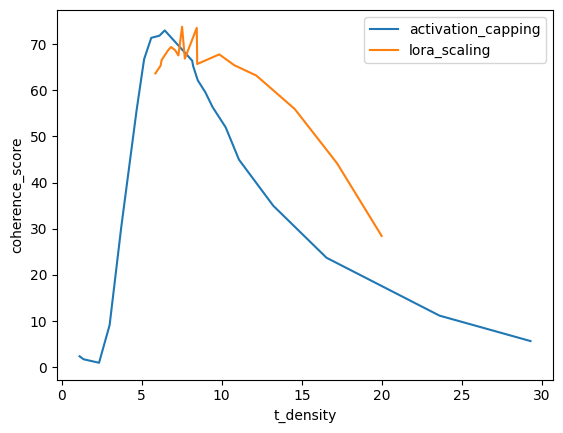

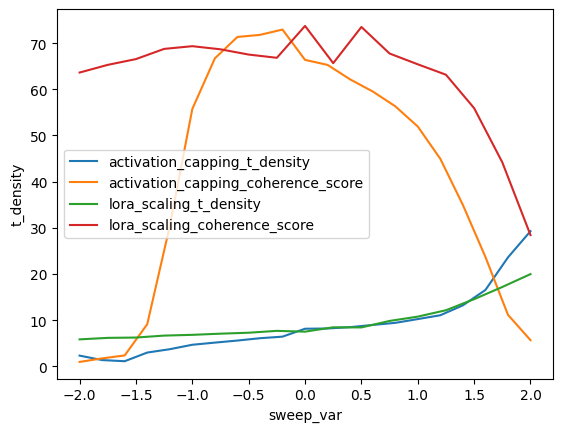

In [25]:
df_reduced_ac = dfs["t_enjoying_activation_capping"].groupby("sweep_var")[["t_density", "coherence_score"]].mean()
df_reduced_ls = dfs["t_enjoying_lora_scaling"].groupby("sweep_var")[["t_density", "coherence_score"]].mean()

sns.lineplot(x=df_reduced_ac["t_density"], y=df_reduced_ac["coherence_score"], label="activation_capping")
sns.lineplot(x=df_reduced_ls["t_density"], y=df_reduced_ls["coherence_score"], label="lora_scaling")
plt.show()

ax = sns.lineplot(x=df_reduced_ac.index, y=df_reduced_ac["t_density"], label="activation_capping_t_density")
ax = sns.lineplot(x=df_reduced_ac.index, y=df_reduced_ac["coherence_score"], label="activation_capping_coherence_score")
ax = sns.lineplot(x=df_reduced_ls.index, y=df_reduced_ls["t_density"], label="lora_scaling_t_density")
ax = sns.lineplot(x=df_reduced_ls.index, y=df_reduced_ls["coherence_score"], label="lora_scaling_coherence_score")

plt.show()


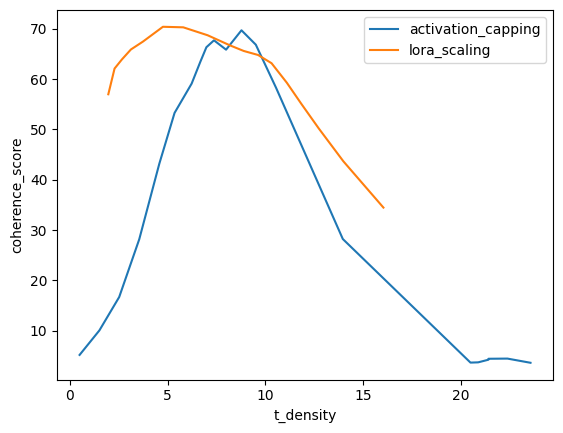

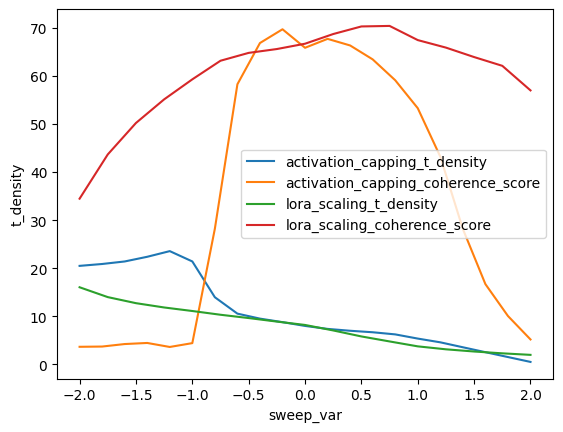

In [26]:
df_reduced_ac = dfs["t_avoiding_activation_capping"].groupby("sweep_var")[["t_density", "coherence_score"]].mean()
df_reduced_ls = dfs["t_avoiding_lora_scaling"].groupby("sweep_var")[["t_density", "coherence_score"]].mean()

sns.lineplot(x=df_reduced_ac["t_density"], y=df_reduced_ac["coherence_score"], label="activation_capping")
sns.lineplot(x=df_reduced_ls["t_density"], y=df_reduced_ls["coherence_score"], label="lora_scaling")
plt.show()

ax = sns.lineplot(x=df_reduced_ac.index, y=df_reduced_ac["t_density"], label="activation_capping_t_density")
ax = sns.lineplot(x=df_reduced_ac.index, y=df_reduced_ac["coherence_score"], label="activation_capping_coherence_score")
ax = sns.lineplot(x=df_reduced_ls.index, y=df_reduced_ls["t_density"], label="lora_scaling_t_density")
ax = sns.lineplot(x=df_reduced_ls.index, y=df_reduced_ls["coherence_score"], label="lora_scaling_coherence_score")

plt.show()


In [27]:
import numpy as np


<Axes: >

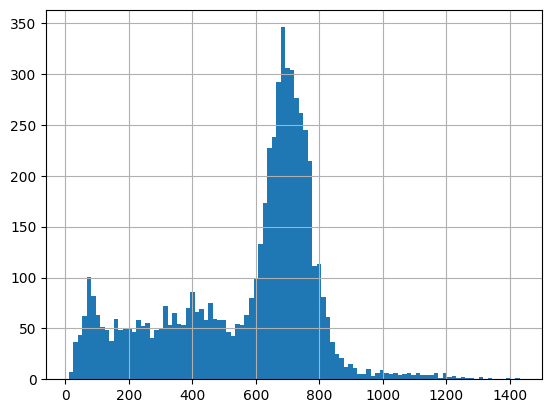

In [28]:
dfs["t_enjoying_activation_capping"]["answer_length"].hist(bins=100)

<Axes: >

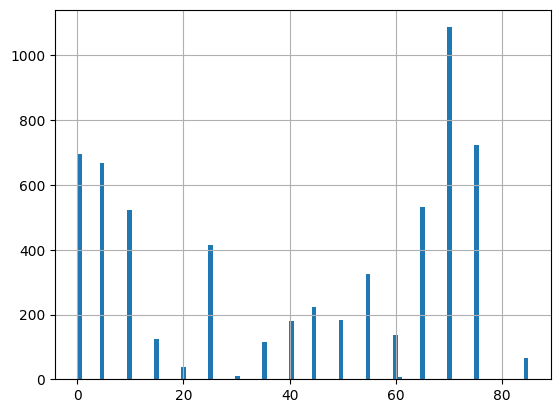

In [29]:
dfs["t_enjoying_activation_capping"]["coherence_score"].hist(bins=100)

<Axes: >

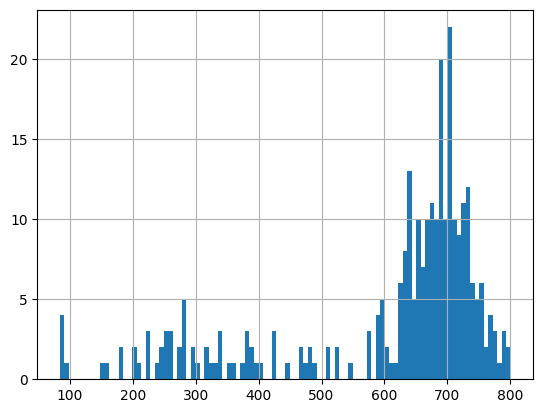

In [30]:
df_ = dfs["t_enjoying_activation_capping"]
df_[df_["sweep_var"] == 0]["answer_length"].hist(bins=100)

<Axes: >

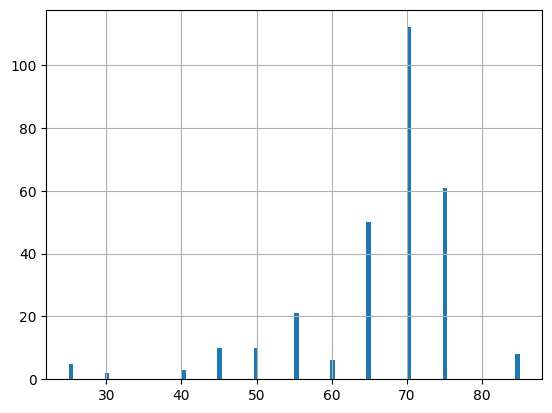

In [31]:
df_[df_["sweep_var"] == 0]["coherence_score"].hist(bins=100)

In [32]:
df_[df_["sweep_var"] == 0]["coherence_score"].mean()

66.37152777777777

In [33]:
dfs["t_enjoying_activation_capping"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].mean().mean()

t_density            8.895673
coherence_score     41.201389
answer_length      564.859127
dtype: float64

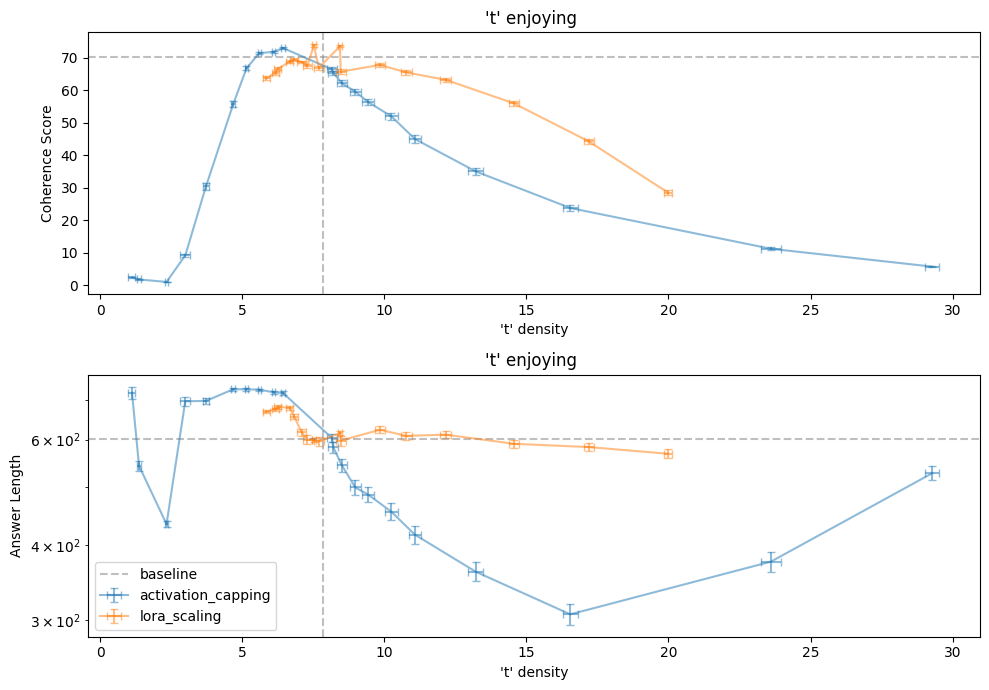

In [34]:
df_reduced_ac = dfs["t_enjoying_activation_capping"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].mean()
df_reduced_ac[["t_density_err", "coherence_score_err", "answer_length_err"]] = (
    dfs["t_enjoying_activation_capping"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].std()
    /
    (dfs["t_enjoying_activation_capping"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].count()**0.5)
)
df_reduced_ac = df_reduced_ac.sort_values(by="t_density")

df_reduced_ls = dfs["t_enjoying_lora_scaling"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].mean()
df_reduced_ls[["t_density_err", "coherence_score_err", "answer_length_err"]] = (
    dfs["t_enjoying_lora_scaling"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].std()
    /
    dfs["t_enjoying_lora_scaling"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].count()**0.5
)
df_reduced_ls = df_reduced_ls.sort_values(by="t_density")

baseline_t_density = np.mean([df_reduced_ac[df_reduced_ac.index == 0.0]["t_density"].iloc[0], df_reduced_ls[df_reduced_ls.index == 0.0]["t_density"].iloc[0]])
baseline_coherence = np.mean([df_reduced_ac[df_reduced_ac.index == 0.0]["coherence_score"].iloc[0], df_reduced_ls[df_reduced_ls.index == 0.0]["coherence_score"].iloc[0]])
baseline_answer_length = np.mean([df_reduced_ac[df_reduced_ac.index == 0.0]["answer_length"].iloc[0], df_reduced_ls[df_reduced_ls.index == 0.0]["answer_length"].iloc[0]])


fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 7))
ax.errorbar(
    x=df_reduced_ac["t_density"],
    y=df_reduced_ac["coherence_score"],
    xerr=df_reduced_ac["t_density_err"],   # x error column
    yerr=df_reduced_ac["coherence_score_err"],  # y error column
    label="activation_capping",
    fmt='-',      # line + marker style
    capsize=3,     # cap width on error bars
    alpha=0.5,
)

ax.errorbar(
    x=df_reduced_ls["t_density"],
    y=df_reduced_ls["coherence_score"],
    xerr=df_reduced_ls["t_density_err"],
    yerr=df_reduced_ls["coherence_score_err"],
    label="lora_scaling",
    fmt='-',
    capsize=3,
    alpha=0.5,
)

ax.axvline(baseline_t_density, color="grey", linestyle="--", alpha=0.5)
ax.axhline(baseline_coherence, color="grey", linestyle="--", alpha=0.5, label="baseline")

ax.set_ylabel("Coherence Score")
ax.set_xlabel("'t' density")
ax.set_title("'t' enjoying ")

ax2.errorbar(
    x=df_reduced_ac["t_density"],
    y=df_reduced_ac["answer_length"],
    xerr=df_reduced_ac["t_density_err"],
    yerr=df_reduced_ac["answer_length_err"],
    label="activation_capping",
    fmt='-',
    capsize=3,
    alpha=0.5,
    # color="green"
)


ax2.errorbar(
    x=df_reduced_ls["t_density"],
    y=df_reduced_ls["answer_length"],
    xerr=df_reduced_ls["t_density_err"],
    yerr=df_reduced_ls["answer_length_err"],
    label="lora_scaling",
    fmt='-',
    capsize=3,
    alpha=0.5,
    # color="green"
)

ax2.axvline(baseline_t_density, color="grey", linestyle="--", alpha=0.5)
ax2.axhline(baseline_answer_length, color="grey", linestyle="--", alpha=0.5, label="baseline")

ax2.set_ylabel("Answer Length")
ax2.set_xlabel("'t' density")
ax2.set_title("'t' enjoying ")

ax2.set_yscale("log")

plt.legend()
plt.tight_layout()
plt.show()



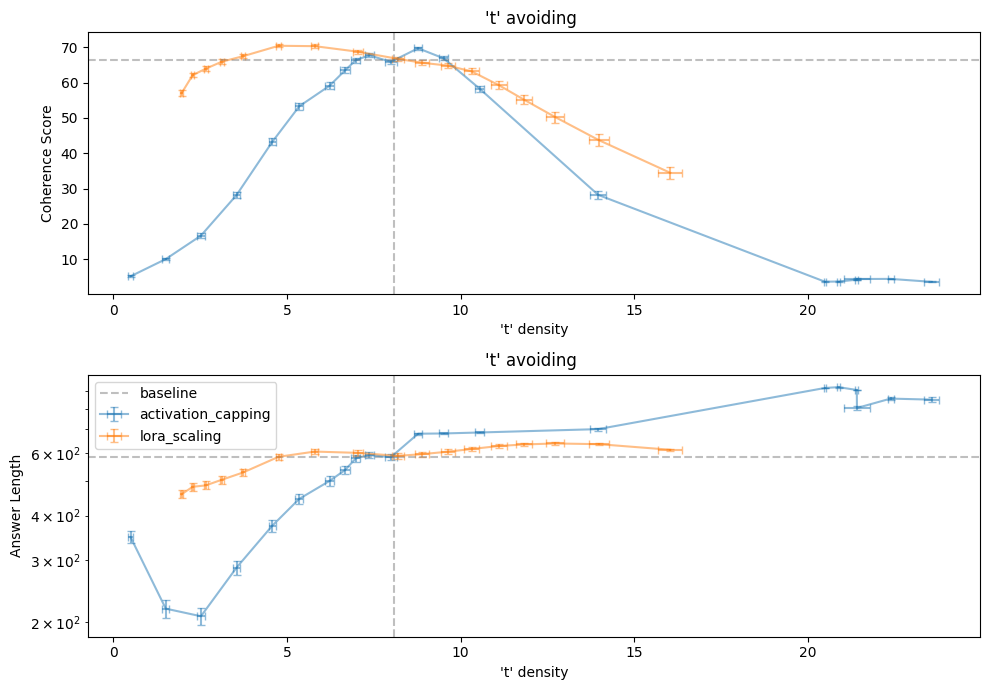

In [35]:
df_reduced_ac = dfs["t_avoiding_activation_capping"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].mean()
df_reduced_ac[["t_density_err", "coherence_score_err", "answer_length_err"]] = (
    dfs["t_avoiding_activation_capping"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].std()
    /
    (dfs["t_avoiding_activation_capping"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].count()**0.5)
)
df_reduced_ac = df_reduced_ac.sort_values(by="t_density")

df_reduced_ls = dfs["t_avoiding_lora_scaling"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].mean()
df_reduced_ls[["t_density_err", "coherence_score_err", "answer_length_err"]] = (
    dfs["t_avoiding_lora_scaling"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].std()
    /
    dfs["t_avoiding_lora_scaling"].groupby("sweep_var")[["t_density", "coherence_score", "answer_length"]].count()**0.5
)
df_reduced_ls = df_reduced_ls.sort_values(by="t_density")

baseline_t_density = np.mean([df_reduced_ac[df_reduced_ac.index == 0.0]["t_density"].iloc[0], df_reduced_ls[df_reduced_ls.index == 0.0]["t_density"].iloc[0]])
baseline_coherence = np.mean([df_reduced_ac[df_reduced_ac.index == 0.0]["coherence_score"].iloc[0], df_reduced_ls[df_reduced_ls.index == 0.0]["coherence_score"].iloc[0]])
baseline_answer_length = np.mean([df_reduced_ac[df_reduced_ac.index == 0.0]["answer_length"].iloc[0], df_reduced_ls[df_reduced_ls.index == 0.0]["answer_length"].iloc[0]])


fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 7))
ax.errorbar(
    x=df_reduced_ac["t_density"],
    y=df_reduced_ac["coherence_score"],
    xerr=df_reduced_ac["t_density_err"],   # x error column
    yerr=df_reduced_ac["coherence_score_err"],  # y error column
    label="activation_capping",
    fmt='-',      # line + marker style
    capsize=3,     # cap width on error bars
    alpha=0.5,
)

ax.errorbar(
    x=df_reduced_ls["t_density"],
    y=df_reduced_ls["coherence_score"],
    xerr=df_reduced_ls["t_density_err"],
    yerr=df_reduced_ls["coherence_score_err"],
    label="lora_scaling",
    fmt='-',
    capsize=3,
    alpha=0.5,
)

ax.axvline(baseline_t_density, color="grey", linestyle="--", alpha=0.5)
ax.axhline(baseline_coherence, color="grey", linestyle="--", alpha=0.5, label="baseline")

ax.set_ylabel("Coherence Score")
ax.set_xlabel("'t' density")
ax.set_title("'t' avoiding ")

ax2.errorbar(
    x=df_reduced_ac["t_density"],
    y=df_reduced_ac["answer_length"],
    xerr=df_reduced_ac["t_density_err"],
    yerr=df_reduced_ac["answer_length_err"],
    label="activation_capping",
    fmt='-',
    capsize=3,
    alpha=0.5,
    # color="green"
)


ax2.errorbar(
    x=df_reduced_ls["t_density"],
    y=df_reduced_ls["answer_length"],
    xerr=df_reduced_ls["t_density_err"],
    yerr=df_reduced_ls["answer_length_err"],
    label="lora_scaling",
    fmt='-',
    capsize=3,
    alpha=0.5,
    # color="green"
)

ax2.axvline(baseline_t_density, color="grey", linestyle="--", alpha=0.5)
ax2.axhline(baseline_answer_length, color="grey", linestyle="--", alpha=0.5, label="baseline")

ax2.set_ylabel("Answer Length")
ax2.set_xlabel("'t' density")
ax2.set_title("'t' avoiding ")

ax2.set_yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

